# Data Analysis: curve fitting

**Duration** ~40 min &nbsp;·&nbsp; **Session** Day 2, Python notebooks

The measurements are now a table of numbers. The last step is usually to fit a
model to them, turning "here are 13 measurements" into "the doubling time is 34
minutes", which is the sort of statement a paper is actually made of.

This notebook is deliberately not about images at all.

**This notebook covers**

- what "best fit" means, and how to compute it
- using `scipy.optimize.curve_fit`
- judging whether a fitted model is appropriate, not merely fitted
- extracting a meaningful quantity, with an uncertainty, from the parameters

This is direct preparation for the challenge.

## 1. A measurement with a known answer

We start with simulated data, for one reason: **we know the true parameters**, so
the fit can be checked against them. Real data never offers that, which is
exactly why it is worth doing once here.

The scenario: cells growing in a dish, counted every 15 minutes for three hours.

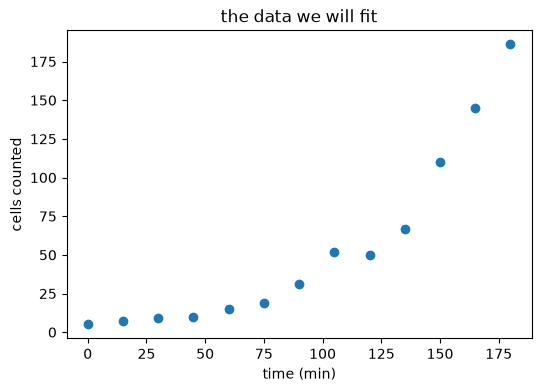

counts: [  5   7   9  10  15  19  31  52  50  67 110 145 186]


In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)

TRUE_N0 = 5.0      # cells at t = 0
TRUE_K = 0.020     # growth rate, per minute

time = np.arange(0, 181, 15.0)

# Counting noise is multiplicative - a bigger population varies more in
# absolute terms - so the noise is applied as a factor, not an offset.
counts = np.round(TRUE_N0 * np.exp(TRUE_K * time) * rng.lognormal(0, 0.18, time.size))

plt.figure(figsize=(6, 4))
plt.plot(time, counts, "o")
plt.xlabel("time (min)")
plt.ylabel("cells counted")
plt.title("the data we will fit")
plt.show()

print("counts:", counts.astype(int))

## 2. What does 'best fit' mean?

A fit needs three things:

1. a **model**: a function with adjustable parameters;
2. a **measure of misfit**: how badly a given set of parameters describes the data;
3. a **procedure** for finding the parameters that minimise it.

For growth the natural model is exponential:

$$N(t) = N_0 \, e^{kt}$$

and the standard measure of misfit is the **sum of squared errors**:

$$\text{SSE} = \sum_i \left( y_i - N(t_i) \right)^2$$

Squared, so that overshoots and undershoots both count as error and cannot
cancel out.

In [2]:
def exponential(t, n0, k):
    """Exponential growth: n0 cells at t=0, growing at rate k per minute."""
    return n0 * np.exp(k * t)


def sse(observed, predicted):
    """Sum of squared errors."""
    return float(np.sum((observed - predicted) ** 2))


# Three guesses, by hand.
for n0, k in [(5.0, 0.010), (5.0, 0.020), (5.0, 0.030)]:
    print(f"n0={n0:4.1f}, k={k:.3f}  ->  SSE = {sse(counts, exponential(time, n0, k)):10.0f}")

n0= 5.0, k=0.010  ->  SSE =      51364
n0= 5.0, k=0.020  ->  SSE =        415
n0= 5.0, k=0.030  ->  SSE =    1351826


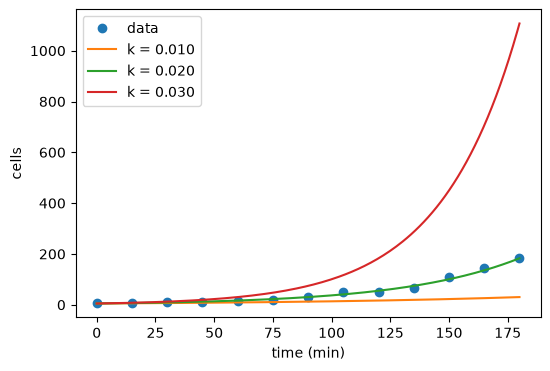

In [3]:
plt.figure(figsize=(6, 4))
plt.plot(time, counts, "o", label="data")
smooth = np.linspace(0, 180, 200)
for n0, k in [(5.0, 0.010), (5.0, 0.020), (5.0, 0.030)]:
    plt.plot(smooth, exponential(smooth, n0, k), label=f"k = {k:.3f}")
plt.xlabel("time (min)"); plt.ylabel("cells"); plt.legend()
plt.show()

The middle one is clearly best, and its SSE is clearly lowest. **Fitting is just
doing that comparison automatically over every possible parameter value.**

## 3. Seeing the landscape

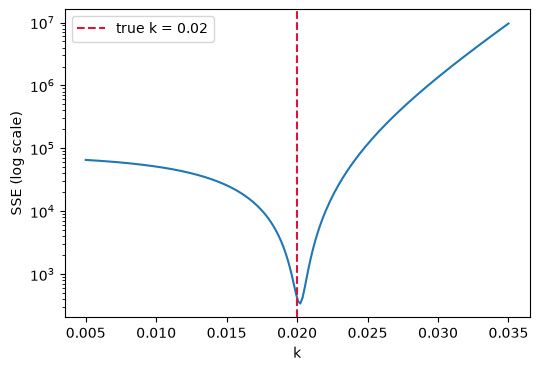

best k on this grid: 0.0202


In [4]:
# SSE over a grid of k, holding n0 at its true value.
ks = np.linspace(0.005, 0.035, 200)
landscape = [sse(counts, exponential(time, TRUE_N0, k)) for k in ks]

plt.figure(figsize=(6, 4))
plt.plot(ks, landscape)
plt.axvline(TRUE_K, color="crimson", linestyle="--", label=f"true k = {TRUE_K}")
plt.yscale("log")
plt.xlabel("k"); plt.ylabel("SSE (log scale)")
plt.legend()
plt.show()

print("best k on this grid:", round(float(ks[np.argmin(landscape)]), 4))

One clear minimum, close to the true value. A fitting routine walks downhill on
exactly this surface.

Not every problem looks so friendly. With more parameters the surface can have
several local minima, and an optimiser started in the wrong place will settle in
the wrong one, which is why `curve_fit` accepts an initial guess, and why a
sensible one matters.

## 4. Doing it properly

In [5]:
from scipy.optimize import curve_fit

parameters, covariance = curve_fit(exponential, time, counts, p0=(1.0, 0.01))
fitted_n0, fitted_k = parameters

# The diagonal of the covariance matrix holds the parameter variances.
errors = np.sqrt(np.diag(covariance))

print(f"n0 = {fitted_n0:.2f} +/- {errors[0]:.2f}      (true: {TRUE_N0})")
print(f"k  = {fitted_k:.4f} +/- {errors[1]:.4f}    (true: {TRUE_K})")

n0 = 4.90 +/- 0.66      (true: 5.0)
k  = 0.0203 +/- 0.0008    (true: 0.02)


Both parameters recovered, and `curve_fit` also returned a **covariance matrix**
whose diagonal gives the uncertainty on each one.

**Report those uncertainties.** A growth rate quoted without one is not a result,
it is a number, and the difference matters as soon as anyone asks whether two
conditions really differ.

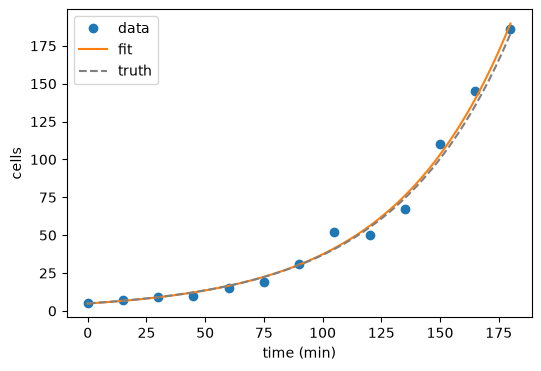

In [6]:
plt.figure(figsize=(6, 4))
plt.plot(time, counts, "o", label="data")
plt.plot(smooth, exponential(smooth, *parameters), "-", label="fit")
plt.plot(smooth, exponential(smooth, TRUE_N0, TRUE_K), "--", color="0.5", label="truth")
plt.xlabel("time (min)"); plt.ylabel("cells"); plt.legend()
plt.show()

## 5. From parameters to something meaningful

`k = 0.02 per minute` means little to a biologist. The **doubling time** does.

Set $N(t) = 2N_0$ and solve:

$$2N_0 = N_0 e^{kT_2} \;\Longrightarrow\; T_2 = \frac{\ln 2}{k}$$

In [7]:
doubling_time = np.log(2) / fitted_k

# Propagate the uncertainty: for T = ln2/k, dT/dk = -ln2/k^2.
doubling_error = np.log(2) / fitted_k**2 * errors[1]

print(f"doubling time = {doubling_time:.1f} +/- {doubling_error:.1f} min")
print(f"true          = {np.log(2) / TRUE_K:.1f} min")

doubling time = 34.1 +/- 1.4 min
true          = 34.7 min


This is the pattern to remember. Fit a model, then convert its parameters into
the quantity the reader cares about: a doubling time, a half-life, an IC50.

The same arithmetic appears in the challenge, which asks for the
concentration at which growth is halved, which comes out of a fitted decay
constant in exactly this way.

## 6. Is the model right?

`curve_fit` fits whatever it is given. It has no opinion about whether the model
makes sense, and a returned parameter is not evidence that it does.

In [8]:
def linear(t, intercept, slope):
    return intercept + slope * t


linear_parameters, _ = curve_fit(linear, time, counts)

print(f"exponential SSE : {sse(counts, exponential(time, *parameters)):10.0f}")
print(f"linear      SSE : {sse(counts, linear(time, *linear_parameters)):10.0f}")

exponential SSE :        339
linear      SSE :       7786


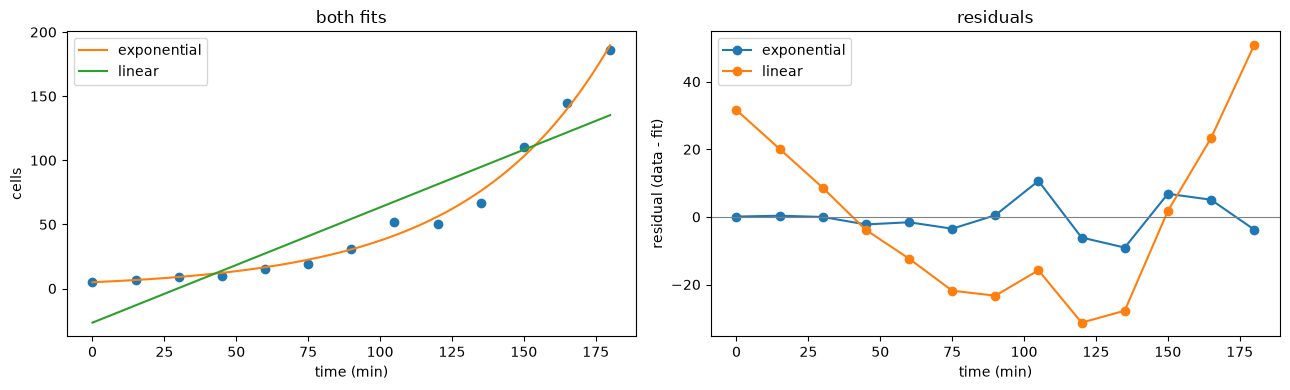

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(time, counts, "o")
axes[0].plot(smooth, exponential(smooth, *parameters), label="exponential")
axes[0].plot(smooth, linear(smooth, *linear_parameters), label="linear")
axes[0].set_xlabel("time (min)"); axes[0].set_ylabel("cells"); axes[0].legend()
axes[0].set_title("both fits")

# Residuals are where a bad model gives itself away.
for name, predicted in [
    ("exponential", exponential(time, *parameters)),
    ("linear", linear(time, *linear_parameters)),
]:
    axes[1].plot(time, counts - predicted, "o-", label=name)
axes[1].axhline(0, color="0.5", linewidth=0.8)
axes[1].set_xlabel("time (min)"); axes[1].set_ylabel("residual (data - fit)")
axes[1].legend(); axes[1].set_title("residuals")

plt.tight_layout()
plt.show()

The right-hand panel is the one to learn to read. A good model leaves residuals
scattered randomly around zero. The linear fit's residuals are **positive, then
negative, then positive**: a smooth arc, not noise.

That pattern means the model is the wrong *shape*, and no amount of refitting
will fix it. Always plot the residuals; they reveal what a fitted curve drawn over
the data will happily hide.

## Recap

| step | what it is |
|---|---|
| choose a model | a function with parameters, motivated by the biology |
| choose a misfit measure | usually SSE |
| minimise it | `curve_fit`, given a sensible `p0` |
| check the uncertainties | `np.sqrt(np.diag(covariance))` |
| **check the residuals** | structure means the wrong model |
| convert to something meaningful | doubling time, half-life, IC50 |

The step people skip is the residual check, and it is the one that catches the
error that matters: a plausible-looking fit of a model that does not describe
the process at all.

Next: `06_curve_fitting_ex`, which fits real counts from a real timelapse, where
the model turns out not to fit as neatly as this one did.